# Task j – Part 2

Topic: Impact of expanding the Spain–France (ES–FR) electricity interconnection

The Iberian Peninsula is often described as an "energy island" due to the limited transmission capacity across the Pyrenees. In 2011, the Spain–France interconnector had a Net Transfer Capacity of only ~1300 MW, far below what would be needed for deep market integration. This is a live EU policy debate: the European Commission has repeatedly called for expanding cross-border interconnection to at least 10% of installed capacity.

In this task, we investigate **how Spain's optimal electricity and heating system changes as the ES–FR interconnection capacity is expanded**, using a parameter sweep over six capacity levels:

- 500 MW – below current capacity (hypothetical low scenario)
- 1300 MW - approximate historical NTC (baseline)
- 2800 MW – capacity used in parts d), g), h), i)
- 5000 MW – moderate expansion
- 8000 MW – large expansion
- 12000 MW – full integration scenario

The model is identical to part i) (electricity + heating sector, co-optimised across Spain, France, Portugal and Morocco). No CO2 constraint is imposed.

In [13]:
import matplotlib.pyplot as plt
import pandas as pd
import pypsa

## Technologies data and costs

In [14]:
year = 2030

url = f"https://raw.githubusercontent.com/PyPSA/technology-data/v0.11.0/outputs/costs_{year}.csv"
costs = pd.read_csv(url, index_col=[0, 1])

costs.loc[costs.unit.str.contains("/kW"), "value"] *= 1e3
costs.unit = costs.unit.str.replace("/kW", "/MW")

defaults = {
    "FOM": 0,
    "VOM": 0,
    "efficiency": 1,
    "fuel": 0,
    "investment": 0,
    "lifetime": 25,
    "CO2 intensity": 0,
    "discount rate": 0.07,
}
costs = costs.value.unstack().fillna(defaults)

costs.at["CCGT", "fuel"] = costs.at["gas", "fuel"]
costs.at["CCGT", "CO2 intensity"] = costs.at["gas", "CO2 intensity"]
costs.at["coal", "CO2 intensity"] = costs.at["coal", "CO2 intensity"]

In [15]:
# calculate annuity
def annuity(r, n):
    return r / (1.0 - 1.0 / (1.0 + r) ** n)

# calculate marginal cost
costs["marginal_cost"] = costs["VOM"] + costs["fuel"] / costs["efficiency"]

annuity_values = costs.apply(lambda x: annuity(x["discount rate"], x["lifetime"]), axis=1)

# calculate capital cost
costs["capital_cost"] = (annuity_values + costs["FOM"] / 100) * costs["investment"]

## Data

In [16]:
# solar capacity factors
data_solar = pd.read_csv('data/pv_optimal.csv', sep=';')
data_solar.index = pd.DatetimeIndex(data_solar['utc_time'])

# wind capacity factors
data_wind = pd.read_csv('data/onshore_wind_1979-2017.csv', sep=';')
data_wind.index = pd.DatetimeIndex(data_wind['utc_time'])

# electricity demand
data_el = pd.read_csv('data/electricity_demand.csv', sep=';')
data_el.index = pd.DatetimeIndex(data_el['utc_time'])

# population-weighted temperature (used to compute time-varying COP)
data_T = pd.read_csv('data/temperature.csv', sep=';')
data_T.index = pd.DatetimeIndex(data_el['utc_time'])

# For this project the chosen country was Spain
country = 'ESP'

In [ ]:
# time-varying COP for Spain

def cop(t_source, t_sink=55):
    delta_t = t_sink - t_source
    return 6.81 - 0.121 * delta_t + 0.00063 * delta_t**2

temp_spain = data_T[country]
cop_spain  = cop(temp_spain)

## Network builder function

The network is identical to part i). The only change is that the ES-FR line capacity is passed as a parameter `es_fr_capacity` instead of being hardcoded to 2800 MW.

In [ ]:
def build_network(es_fr_capacity):

    # build the full network from parts d) and g), extended with the heating sector

    n = pypsa.Network()

    hours = pd.date_range('2011-01-01 00:00Z', '2011-12-31 23:00Z', freq='h')
    n.set_snapshots(hours.values)

    # Carriers
    n.add("Carrier", "onwind", color="dodgerblue",  co2_emissions=0.0)
    n.add("Carrier", "solar",  color="gold",         co2_emissions=0.0)
    n.add("Carrier", "coal",   color="indianred",     co2_emissions=costs.at["coal", "CO2 intensity"])
    n.add("Carrier", "CCGT",   color="yellowgreen",   co2_emissions=costs.at["gas",  "CO2 intensity"])
    n.add("Carrier", "PHS",    color="brown",         co2_emissions=0.0)
    n.add("Carrier", "gas",    color="orange",        co2_emissions=costs.at["gas",  "CO2 intensity"])
    n.add("Carrier", "H2",     color="lightblue",     co2_emissions=0.0)
    n.add("Carrier", "heat",   color="firebrick",     co2_emissions=0.0)

    # ELECTRICITY BUSES
    n.add("Bus", "Spain electricity", carrier="AC")
    n.add("Bus", "FR",                carrier="AC")
    n.add("Bus", "PT",                carrier="AC")
    n.add("Bus", "MA",                carrier="AC")

    # GAS BUSES (CH4)
    n.add("Bus", "Spain gas", carrier="gas")
    n.add("Bus", "FR gas",    carrier="gas")
    n.add("Bus", "PT gas",    carrier="gas")
    n.add("Bus", "MA gas",    carrier="gas")

    # H2 BUSES
    n.add("Bus", "Spain H2",  carrier="H2")
    n.add("Bus", "FR H2",     carrier="H2")
    n.add("Bus", "PT H2",     carrier="H2")
    n.add("Bus", "MA H2",     carrier="H2")

    # HEAT BUSES (new in task i)
    n.add("Bus", "Spain heat", carrier="heat")
    n.add("Bus", "FR heat",    carrier="heat")
    n.add("Bus", "PT heat",    carrier="heat")
    n.add("Bus", "MA heat",    carrier="heat")

    # ELECTRICITY LOADS

    # Spain (hourly from data)
    n.add("Load", "demand",
          bus="Spain electricity",
          p_set=data_el[country].values)

    # Neighbours (constant average MW)
    # (same as part d))
    demand_avg_mw = {
        "FR": 468e6 / 8760,# ~53,425 MW - France 2011 ~468 TWh (Enerdata)
        "PT": 48e6  / 8760,# ~5,479 MW  - Portugal 2011 ~48 TWh (REN)
        "MA": 28e6  / 8760,# ~3,196 MW  - Morocco 2011 ~28 TWh (IEA)
    }

    for country_code, p_set in demand_avg_mw.items():
        n.add("Load", f"load_{country_code}", bus=country_code, p_set=p_set)

    # HEAT LOADS (new in task i)

    heat_demand_mw = {
        "Spain heat": 182e6 / 8760,
        "FR heat":    462e6 / 8760,
        "PT heat":    32e6  / 8760,
        "MA heat":    10e6  / 8760,
    }

    for bus, p_set in heat_demand_mw.items():
        n.add("Load", f"heat load {bus}",
              bus=bus,
              carrier="heat",
              p_set=p_set)

    # SPAIN ELECTRICITY GENERATORS (extendable, co-optimised)

    CF_wind  = data_wind[country][[hour.strftime("%Y-%m-%dT%H:%M:%SZ") for hour in n.snapshots]]
    CF_solar = data_solar[country][[hour.strftime("%Y-%m-%dT%H:%M:%SZ") for hour in n.snapshots]]

    n.add("Generator", "CCGT",
          bus="Spain electricity",
          carrier="CCGT",
          capital_cost=costs.at["CCGT", "capital_cost"],
          marginal_cost=costs.at["CCGT", "marginal_cost"],
          efficiency=costs.at["CCGT", "efficiency"],
          p_nom_extendable=True,
          p_nom_max=25300)

    n.add("Generator", "coal",
          bus="Spain electricity",
          carrier="coal",
          capital_cost=costs.at["coal", "capital_cost"],
          marginal_cost=costs.at["coal", "marginal_cost"],
          efficiency=costs.at["coal", "efficiency"],
          p_nom_extendable=True,
          p_nom_max=11700)

    n.add("Generator", "onwind",
          bus="Spain electricity",
          carrier="onwind",
          p_max_pu=CF_wind.values,
          capital_cost=costs.at["onwind", "capital_cost"],
          marginal_cost=costs.at["onwind", "marginal_cost"],
          efficiency=costs.at["onwind", "efficiency"],
          p_nom_extendable=True)

    n.add("Generator", "solar",
          bus="Spain electricity",
          carrier="solar",
          p_max_pu=CF_solar.values,
          capital_cost=costs.at["solar", "capital_cost"],
          marginal_cost=costs.at["solar", "marginal_cost"],
          efficiency=costs.at["solar", "efficiency"],
          p_nom_extendable=True)

    # Pumped hydro storage
    n.add("StorageUnit", "PHS",
          bus="Spain electricity",
          carrier="PHS",
          max_hours=6,
          capital_cost=costs.at["PHS", "capital_cost"],
          marginal_cost=costs.at["PHS", "marginal_cost"],
          efficiency_store=costs.at["PHS", "efficiency"]**0.5,
          efficiency_dispatch=costs.at["PHS", "efficiency"]**0.5,
          p_nom_extendable=True,
          cyclic_state_of_charge=True)

    # NEIGHBOUR ELECTRICITY GENERATORS (fixed capacity)
    # same as section d)

    neighbour_generators = {
        "FR": [
            ("nuclear_FR", "CCGT",   63000, 1.0,  5.0),
            ("wind_FR",    "onwind",  6600,  1.0,  1.4),
        ],
        "PT": [
            ("wind_PT",    "onwind",  4378,  1.0,  1.4),
            ("gas_PT",     "CCGT",    3800,  1.0, 46.8),
        ],
        "MA": [
            ("thermal_MA", "CCGT",    4771,  1.0, 46.8),
            ("wind_MA",    "onwind",   292,  1.0,  1.4),
        ],
    }

    for country_code, gens in neighbour_generators.items():
        for name, carrier, p_nom, cf, mc in gens:
            n.add("Generator", name,
                  bus=country_code,
                  carrier=carrier,
                  p_nom=p_nom,
                  p_nom_extendable=False,
                  p_max_pu=cf,
                  marginal_cost=mc)

    # HVAC ELECTRICITY LINES (same as part d, fixed capacities)
    # The FR-PT line closes the triangular cycle: Spain -> FR -> PT -> Spain
    # ES-FR capacity is the only parameter that changes across sweep runs

    elec_lines = [
        ("ES-FR",  "Spain electricity", "FR",  es_fr_capacity, 0.1),  # <-- swept
        ("ES-PT",  "Spain electricity", "PT",  3000,           0.1),
        ("FR-PT",  "FR",               "PT",  2200,           0.1),
        ("ES-MA",  "Spain electricity", "MA",   900,           0.1),
    ]

    for name, bus0, bus1, s_nom, x in elec_lines:
        n.add("Line", name,
              bus0=bus0, bus1=bus1,
              s_nom=s_nom,
              s_nom_extendable=False,
              x=x,
              v_nom=400)

    # GAS SUPPLY (generators on gas buses)
    # Represents LNG terminals, domestic production and imports.

    gas_mc = costs.at["gas", "fuel"]  # EUR/MWh_th

    for bus in ["Spain gas", "FR gas", "PT gas", "MA gas"]:
        n.add("Generator", f"gas supply {bus}",
              bus=bus,
              carrier="gas",
              p_nom_extendable=True,
              marginal_cost=gas_mc,
              capital_cost=0)

    # H2 SUPPLY (generators on H2 buses)

    h2_mc = 70  # EUR/MWh_th (same as g))

    for bus in ["Spain H2", "FR H2", "PT H2", "MA H2"]:
        n.add("Generator", f"H2 supply {bus}",
              bus=bus,
              carrier="H2",
              p_nom_extendable=True,
              marginal_cost=h2_mc,
              capital_cost=0)

    # GAS AND H2 NON-POWER SECTOR LOADS
    # same as part g)

    gas_demand_mw = {
        "Spain gas": 200e6 / 8760,
        "FR gas":    300e6 / 8760,
        "PT gas":     35e6 / 8760,
        "MA gas":     10e6 / 8760,
    }

    for bus, p_set in gas_demand_mw.items():
        n.add("Load", f"gas load {bus}", bus=bus, carrier="gas", p_set=p_set)

    h2_demand_mw = {
        "Spain H2": 10e6 / 8760,
        "FR H2":    15e6 / 8760,
        "PT H2":     2e6 / 8760,
        "MA H2":     1e6 / 8760,
    }

    for bus, p_set in h2_demand_mw.items():
        n.add("Load", f"H2 load {bus}", bus=bus, carrier="H2", p_set=p_set)

    # CH4 GAS PIPELINES (Links between gas buses)
    # Linear gas transport: efficiency=1 (no losses), bidirectional.
    # same as part g)

    gas_pipelines = [
        ("gas ES-FR",  "Spain gas",  "FR gas",   7500),
        ("gas ES-PT",  "Spain gas",  "PT gas",   4000),
        ("gas ES-MA",  "Spain gas",  "MA gas",   5700),
        ("gas FR-PT",  "FR gas",     "PT gas",   2000),
    ]

    for name, bus0, bus1, p_nom in gas_pipelines:
        n.add("Link", name,
              bus0=bus0, bus1=bus1,
              p_nom=p_nom, p_nom_extendable=False,
              efficiency=1.0, marginal_cost=0.0, carrier="gas")
        n.add("Link", name + " rev",
              bus0=bus1, bus1=bus0,
              p_nom=p_nom, p_nom_extendable=False,
              efficiency=1.0, marginal_cost=0.0, carrier="gas")

    # H2 PIPELINES (Links between H2 buses)
    # ~20% of gas pipeline capacity repurposed for H2.
    # same as part g)

    h2_pipelines = [
        ("H2 ES-FR",  "Spain H2",  "FR H2",   1500),
        ("H2 ES-PT",  "Spain H2",  "PT H2",    800),
        ("H2 ES-MA",  "Spain H2",  "MA H2",   1140),
        ("H2 FR-PT",  "FR H2",     "PT H2",    400),
    ]

    for name, bus0, bus1, p_nom in h2_pipelines:
        n.add("Link", name,
              bus0=bus0, bus1=bus1,
              p_nom=p_nom, p_nom_extendable=False,
              efficiency=1.0, marginal_cost=0.0, carrier="H2")
        n.add("Link", name + " rev",
              bus0=bus1, bus1=bus0,
              p_nom=p_nom, p_nom_extendable=False,
              efficiency=1.0, marginal_cost=0.0, carrier="H2")

    # HEAT PUMPS (electricity bus -> heat bus)
    # For Spain: time-varying COP from ambient temperature (same approach as Problem 11.1).
    # For neighbouring countries: constant COP = 3.0 (temperature data not available).
    # Capital cost: central air-sourced heat pump from PyPSA Technology Data v0.11.0.

    n.add(
        "Link",
        "heat pump Spain",
        bus0="Spain electricity",
        bus1="Spain heat",
        carrier="heat",
        efficiency=cop_spain.values,
        capital_cost=costs.at["central air-sourced heat pump", "capital_cost"],
        marginal_cost=costs.at["central air-sourced heat pump", "marginal_cost"],
        p_nom_extendable=True,
    )

    for country_code, elec_bus, heat_bus in [
        ("FR", "FR", "FR heat"),
        ("PT", "PT", "PT heat"),
        ("MA", "MA", "MA heat"),
    ]:
        n.add(
            "Link",
            f"heat pump {country_code}",
            bus0=elec_bus,
            bus1=heat_bus,
            carrier="heat",
            efficiency=3.0,
            capital_cost=costs.at["central air-sourced heat pump", "capital_cost"],
            marginal_cost=costs.at["central air-sourced heat pump", "marginal_cost"],
            p_nom_extendable=True,
        )

    # GAS BOILERS (gas bus -> heat bus)
    # Convert gas to heat with efficiency = 0.9.

    for country_code, gas_bus, heat_bus in [
        ("Spain", "Spain gas",  "Spain heat"),
        ("FR",    "FR gas",     "FR heat"),
        ("PT",    "PT gas",     "PT heat"),
        ("MA",    "MA gas",     "MA heat"),
    ]:
        n.add(
            "Link",
            f"gas boiler {country_code}",
            bus0=gas_bus,
            bus1=heat_bus,
            carrier="heat",
            efficiency=costs.at["central gas boiler", "efficiency"],
            capital_cost=costs.at["central gas boiler", "capital_cost"],
            marginal_cost=costs.at["central gas boiler", "marginal_cost"],
            p_nom_extendable=True,
        )

    # fix ArrowStringArray dtype issue (same fix as all previous parts)

    for df in [n.buses, n.loads, n.generators, n.lines, n.links, n.storage_units, n.carriers]:
        for col in df.columns:
            if "ArrowStringArray" in str(type(df[col].array)):
                df[col] = df[col].astype("object")
        df.index = pd.Index(df.index.tolist(), dtype=object)
        df.index.name = "name"

    return n

## Parameter sweep

We run the model for each ES-FR capacity level and collect the key results for Spain:
- Total system cost (billion EUR/year)
- Optimal installed capacity of each electricity generator (GW)
- Net electricity imports from France (TWh/year, positive = Spain imports)
- Optimal heat pump and gas boiler capacity (GW)
- Annual heat mix: heat pump vs gas boiler (TWh/year)

In [ ]:
# ES-FR capacity levels to sweep (MW)
es_fr_levels = [500, 1300, 2800, 5000, 8000, 12000]

# Results storage
results = {}

for cap in es_fr_levels:
    print(f"\n--- Running ES-FR = {cap} MW ---")
    n = build_network(es_fr_capacity=cap)
    n.optimize(solver_name="highs")

    print(f"  ES-FR p0 mean: {n.lines_t.p0['ES-FR'].mean():.2f} MW")  # <-- add this line
    print(f"  (positive = Spain exports to France, negative = Spain imports from France)")


    spain_gens = n.generators[n.generators.bus == "Spain electricity"]

    # Net imports from France via ES-FR line
    # p0 is power leaving Spain's bus; negative p0 means Spain is importing
    net_imports_fr_twh = -n.lines_t.p0["ES-FR"].sum() / 1e6  # TWh, positive = Spain imports

    results[cap] = {
        # System cost
        "system_cost_bn": n.objective / 1e9,

        # Spain electricity generation capacities (GW)
        "wind_GW":  n.generators.loc["onwind", "p_nom_opt"] / 1e3,
        "solar_GW": n.generators.loc["solar",  "p_nom_opt"] / 1e3,
        "CCGT_GW":  n.generators.loc["CCGT",   "p_nom_opt"] / 1e3,
        "coal_GW":  n.generators.loc["coal",   "p_nom_opt"] / 1e3,

        # Net imports from France (TWh/year, positive = Spain imports)
        "net_imports_FR_TWh": net_imports_fr_twh,

        # Spain heat sector capacities (GW)
        "heat_pump_GW":  n.links.loc["heat pump Spain",  "p_nom_opt"] / 1e3,
        "gas_boiler_GW": n.links.loc["gas boiler Spain", "p_nom_opt"] / 1e3,

        # Spain annual heat generation (TWh/year)
        "heat_pump_TWh":  -n.links_t.p1["heat pump Spain"].sum()  / 1e6,
        "gas_boiler_TWh": -n.links_t.p1["gas boiler Spain"].sum() / 1e6,
    }

    print(f"  System cost:        {results[cap]['system_cost_bn']:.3f} bn EUR/yr")
    print(f"  Wind:               {results[cap]['wind_GW']:.1f} GW")
    print(f"  Solar:              {results[cap]['solar_GW']:.1f} GW")
    print(f"  CCGT:               {results[cap]['CCGT_GW']:.1f} GW")
    print(f"  Coal:               {results[cap]['coal_GW']:.1f} GW")
    print(f"  Net imports FR:     {results[cap]['net_imports_FR_TWh']:.1f} TWh/yr")
    print(f"  Heat pump (Spain):  {results[cap]['heat_pump_GW']:.2f} GW")
    print(f"  Gas boiler (Spain): {results[cap]['gas_boiler_GW']:.2f} GW")

df_results = pd.DataFrame(results).T
df_results.index.name = "ES-FR capacity (MW)"
print("\n=== Summary table ===")
print(df_results.round(2))


--- Running ES-FR = 500 MW ---


C:\Users\mmont\AppData\Local\Temp\ipykernel_31056\1205720291.py:10: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n.optimize(solver_name="highs")
Index(['Spain electricity', 'FR', 'PT', 'MA'], dtype='object', name='name')
Index(['ES-FR', 'ES-PT', 'FR-PT', 'ES-MA'], dtype='object', name='name')
Index(['ES-FR', 'ES-PT', 'FR-PT', 'ES-MA'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 9/9 [00:00<00:00, 189.01it/s]
INFO:linopy.io: Writing time: 0.59s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 429261 primals, 1016183 duals
Objective: 4.32e+10
Solver model: available
Solver message: O

  System cost:        43.172 bn EUR/yr
  Wind:               4.3 GW
  Solar:              76.6 GW
  CCGT:               25.3 GW
  Coal:               4.1 GW
  Net imports FR:     -3.9 TWh/yr
  Heat pump (Spain):  6.49 GW
  Gas boiler (Spain): 19.98 GW

--- Running ES-FR = 1300 MW ---


C:\Users\mmont\AppData\Local\Temp\ipykernel_31056\1205720291.py:10: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n.optimize(solver_name="highs")
Index(['Spain electricity', 'FR', 'PT', 'MA'], dtype='object', name='name')
Index(['ES-FR', 'ES-PT', 'FR-PT', 'ES-MA'], dtype='object', name='name')
Index(['ES-FR', 'ES-PT', 'FR-PT', 'ES-MA'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 9/9 [00:00<00:00, 117.99it/s]
INFO:linopy.io: Writing time: 0.79s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 429261 primals, 1016183 duals
Objective: 4.29e+10
Solver model: available
Solver message: O

  System cost:        42.929 bn EUR/yr
  Wind:               4.1 GW
  Solar:              80.6 GW
  CCGT:               25.3 GW
  Coal:               3.3 GW
  Net imports FR:     -4.6 TWh/yr
  Heat pump (Spain):  6.40 GW
  Gas boiler (Spain): 19.98 GW

--- Running ES-FR = 2800 MW ---


...

  System cost:        42.293 bn EUR/yr
  Wind:               4.1 GW
  Solar:              74.7 GW
  CCGT:               25.3 GW
  Coal:               3.8 GW
  Net imports FR:     -3.9 TWh/yr
  Heat pump (Spain):  6.36 GW
  Gas boiler (Spain): 19.98 GW

--- Running ES-FR = 8000 MW ---


C:\Users\mmont\AppData\Local\Temp\ipykernel_31056\1205720291.py:10: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n.optimize(solver_name="highs")
Index(['Spain electricity', 'FR', 'PT', 'MA'], dtype='object', name='name')
Index(['ES-FR', 'ES-PT', 'FR-PT', 'ES-MA'], dtype='object', name='name')
Index(['ES-FR', 'ES-PT', 'FR-PT', 'ES-MA'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 9/9 [00:00<00:00, 180.82it/s]
INFO:linopy.io: Writing time: 0.49s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 429261 primals, 1016183 duals
Objective: 4.23e+10
Solver model: available
Solver message: O

  System cost:        42.272 bn EUR/yr
  Wind:               4.1 GW
  Solar:              74.3 GW
  CCGT:               25.3 GW
  Coal:               3.8 GW
  Net imports FR:     -3.7 TWh/yr
  Heat pump (Spain):  6.36 GW
  Gas boiler (Spain): 19.98 GW

--- Running ES-FR = 12000 MW ---


C:\Users\mmont\AppData\Local\Temp\ipykernel_31056\1205720291.py:10: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  n.optimize(solver_name="highs")
Index(['Spain electricity', 'FR', 'PT', 'MA'], dtype='object', name='name')
Index(['ES-FR', 'ES-PT', 'FR-PT', 'ES-MA'], dtype='object', name='name')
Index(['ES-FR', 'ES-PT', 'FR-PT', 'ES-MA'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 9/9 [00:00<00:00, 137.79it/s]
INFO:linopy.io: Writing time: 0.5s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 429261 primals, 1016183 duals
Objective: 4.23e+10
Solver model: available
Solver message: Op

  System cost:        42.272 bn EUR/yr
  Wind:               4.1 GW
  Solar:              74.3 GW
  CCGT:               25.3 GW
  Coal:               3.8 GW
  Net imports FR:     -3.7 TWh/yr
  Heat pump (Spain):  6.36 GW
  Gas boiler (Spain): 19.98 GW

=== Summary table ===
                     system_cost_bn  wind_GW  solar_GW  CCGT_GW  coal_GW  \
ES-FR capacity (MW)                                                        
500                           43.17     4.28     76.56     25.3     4.07   
1300                          42.93     4.08     80.62     25.3     3.28   
2800                          42.60     4.08     78.52     25.3     3.66   
5000                          42.29     4.08     74.66     25.3     3.81   
8000                          42.27     4.08     74.31     25.3     3.81   
12000                         42.27     4.08     74.31     25.3     3.81   

                     net_imports_FR_TWh  heat_pump_GW  gas_boiler_GW  \
ES-FR capacity (MW)                         

## Results and plots

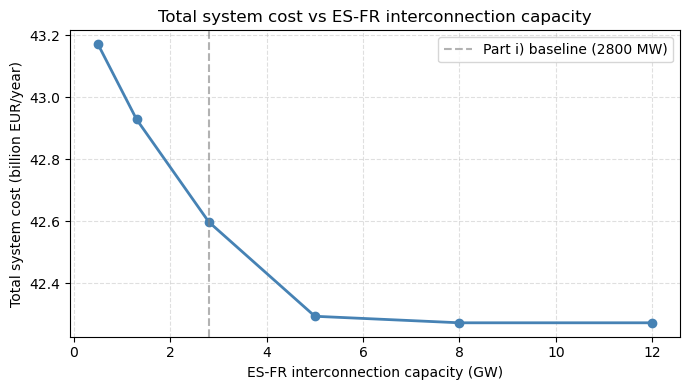

In [ ]:
# --- PLOT 1: Total system cost vs ES-FR capacity ---

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(df_results.index / 1e3, df_results["system_cost_bn"], marker="o", color="steelblue", linewidth=2)
ax.axvline(x=2.8, color="grey", linestyle="--", alpha=0.6, label="Part i) baseline (2800 MW)")
ax.set_xlabel("ES-FR interconnection capacity (GW)")
ax.set_ylabel("Total system cost (billion EUR/year)")
ax.set_title("Total system cost vs ES-FR interconnection capacity")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

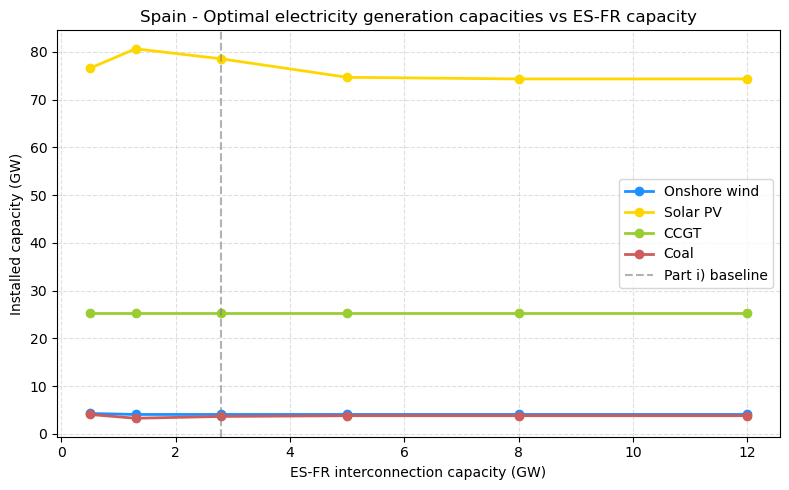

In [ ]:
# --- PLOT 2: Spain optimal electricity generation capacities vs ES-FR capacity ---

fig, ax = plt.subplots(figsize=(8, 5))

colors = {"wind_GW": "dodgerblue", "solar_GW": "gold", "CCGT_GW": "yellowgreen", "coal_GW": "indianred"}
labels = {"wind_GW": "Onshore wind", "solar_GW": "Solar PV", "CCGT_GW": "CCGT", "coal_GW": "Coal"}

x = df_results.index / 1e3  # convert to GW for x-axis
for col, color in colors.items():
    ax.plot(x, df_results[col], marker="o", label=labels[col], color=color, linewidth=2)

ax.axvline(x=2.8, color="grey", linestyle="--", alpha=0.6, label="Part i) baseline")
ax.set_xlabel("ES-FR interconnection capacity (GW)")
ax.set_ylabel("Installed capacity (GW)")
ax.set_title("Spain - Optimal electricity generation capacities vs ES-FR capacity")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()